# Migraine Dataset Analysis

**Define the Objective** 

Predict the type of migraine based on patient symptoms and demographics.

Attribute Information:
1) Age: Patient's age
2) Duration: duration of symptoms in last episode in days
3) Frequency: Frequency of episodes per month
4) Location: Unilateral or bilateral pain location (None - 0, Unilateral - 1, Bilateral - 2)
5) Character: Throbbing or constant pain (None - 0, Thobbing - 1, Constant - 2)
6) Intensity: Pain intensity, i.e., mild, medium, or severe (None - 0, Mild - 1, Medium - 2, Severe - 3)
7) Nausea: Nauseous feeling (Not - 0, Yes - 1)
8) Vomit: Vomiting (Not - 0, Yes - 1)
9) Phonophobia: Noise sensitivity (Not - 0, Yes - 1)
10) Photophobia: Light sensitivity (Not - 0, Yes - 1)
11) Visual: Number of reversible visual symptoms
12) Sensory: Number of reversible sensory symptoms
13) Dysphasia: Lack of speech coordination (Not - 0, Yes - 1)
14) Dysarthria: Disarticulated sounds and words (Not - 0, Yes - 1)
15) Vertigo: Dizziness (Not - 0, Yes - 1)
16) Tinnitus: Ringing in the ears (Not - 0, Yes - 1)
17) Hypoacusis: Hearing loss (Not - 0, Yes - 1)
18) Diplopia: Double vision (Not - 0, Yes - 1)
19) Visual defect: Simultaneous frontal eye field and nasal field defect and in both eyes (Not - 0, Yes - 1)
20) Ataxia: Lack of muscle control (Not - 0, Yes - 1)
21) Conscience: Jeopardized conscience (Not - 0, Yes - 1)
22) Paresthesia: Simultaneous bilateral paresthesia (Not - 0, Yes - 1)
23) DPF: Family background (Not - 0, Yes - 1)
24) Type: Diagnosis of migraine type (Typical aura with migraine, Migraine without aura, Typical aura without migraine, Familial hemiplegic migraine, Sporadic hemiplegic migraine, Basilar-type aura, Other) [247, 60, 20, 24, 14, 18, 17]

In [1]:
# Load necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Loading and Exploration

In [2]:
# load dataset
df = pd.read_csv('migraine_data.csv')

In [3]:
df.shape

(400, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          400 non-null    int64 
 1   Duration     400 non-null    int64 
 2   Frequency    400 non-null    int64 
 3   Location     400 non-null    int64 
 4   Character    400 non-null    int64 
 5   Intensity    400 non-null    int64 
 6   Nausea       400 non-null    int64 
 7   Vomit        400 non-null    int64 
 8   Phonophobia  400 non-null    int64 
 9   Photophobia  400 non-null    int64 
 10  Visual       400 non-null    int64 
 11  Sensory      400 non-null    int64 
 12  Dysphasia    400 non-null    int64 
 13  Dysarthria   400 non-null    int64 
 14  Vertigo      400 non-null    int64 
 15  Tinnitus     400 non-null    int64 
 16  Hypoacusis   400 non-null    int64 
 17  Diplopia     400 non-null    int64 
 18  Defect       400 non-null    int64 
 19  Ataxia       400 non-null    

**Data Preprocessing**

In [5]:
# check for missing values 
df.isnull().sum()

Age            0
Duration       0
Frequency      0
Location       0
Character      0
Intensity      0
Nausea         0
Vomit          0
Phonophobia    0
Photophobia    0
Visual         0
Sensory        0
Dysphasia      0
Dysarthria     0
Vertigo        0
Tinnitus       0
Hypoacusis     0
Diplopia       0
Defect         0
Ataxia         0
Conscience     0
Paresthesia    0
DPF            0
Type           0
dtype: int64

In [6]:
# check for duplicated rows
print("there are", df.duplicated().sum(), "duplicates")

there are 6 duplicates


In [7]:
# drop 6 duplicated rows
df.drop_duplicates(inplace=True)

In [8]:
# confirm droped rows
df.shape

(394, 24)

<Axes: xlabel='count', ylabel='Type'>

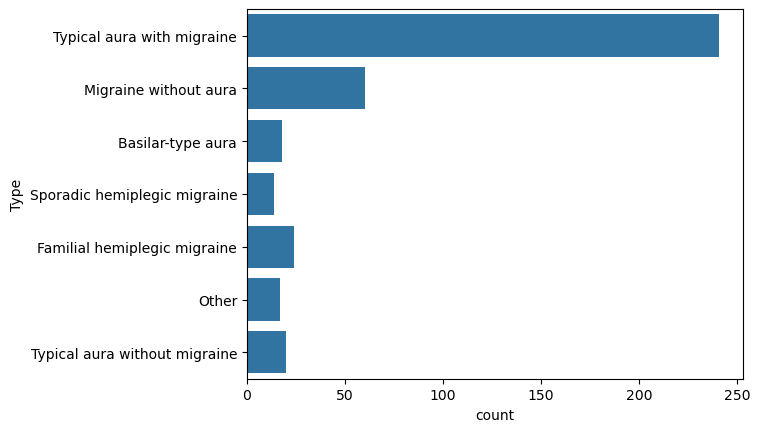

In [9]:
# look at target variable spread
sns.countplot(y=df['Type'])

In [10]:
#quantify imbalance 
df['Type'].value_counts(normalize=True) * 100

Type
Typical aura with migraine       61.167513
Migraine without aura            15.228426
Familial hemiplegic migraine      6.091371
Typical aura without migraine     5.076142
Basilar-type aura                 4.568528
Other                             4.314721
Sporadic hemiplegic migraine      3.553299
Name: proportion, dtype: float64

### Data Observations

1. The dataeset contains 400 records and 24 columns.
2. The data is clean with no missing values
3. Their are 6 duplicates that were removed. 
4. The 'Type' column is an object type, meaning it is categorical. Therefore I need to encode it into numerical values. Use LabelEncoder to transform mimraine types into numerical labels suited for machine models
5. The distribution of the types is not equal this is something to watch out for since a majority of the data sets are typical aura with migraine type.

## Premodeling adjustments

In [11]:
# Encode Target Variable
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

In [12]:
# Separate input features (X) from the target variable (y)
X = df.drop(['Type', 'Type_encoded'], axis=1)
y = df['Type_encoded']

In [13]:
# Standardize features to improve model performance and convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Split Data into Training and Test Set
# Use stratification to ensure class proportions are preserved and reduce sampling bias
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
# Apply SMOTE to address Class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

## Models

In [16]:
# Initialize Models 
models = {
    'Logistic Regression': LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y)),
        eval_metric='mlogloss',
        use_label_encoder=False
    )
}


Model: Logistic Regression
Classification Report:
                                precision    recall  f1-score   support

            Basilar-type aura       0.75      0.75      0.75         4
 Familial hemiplegic migraine       0.36      1.00      0.53         5
        Migraine without aura       0.86      1.00      0.92        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       0.40      0.67      0.50         3
   Typical aura with migraine       0.97      0.73      0.83        48
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.80        79
                    macro avg       0.76      0.83      0.76        79
                 weighted avg       0.89      0.80      0.82        79



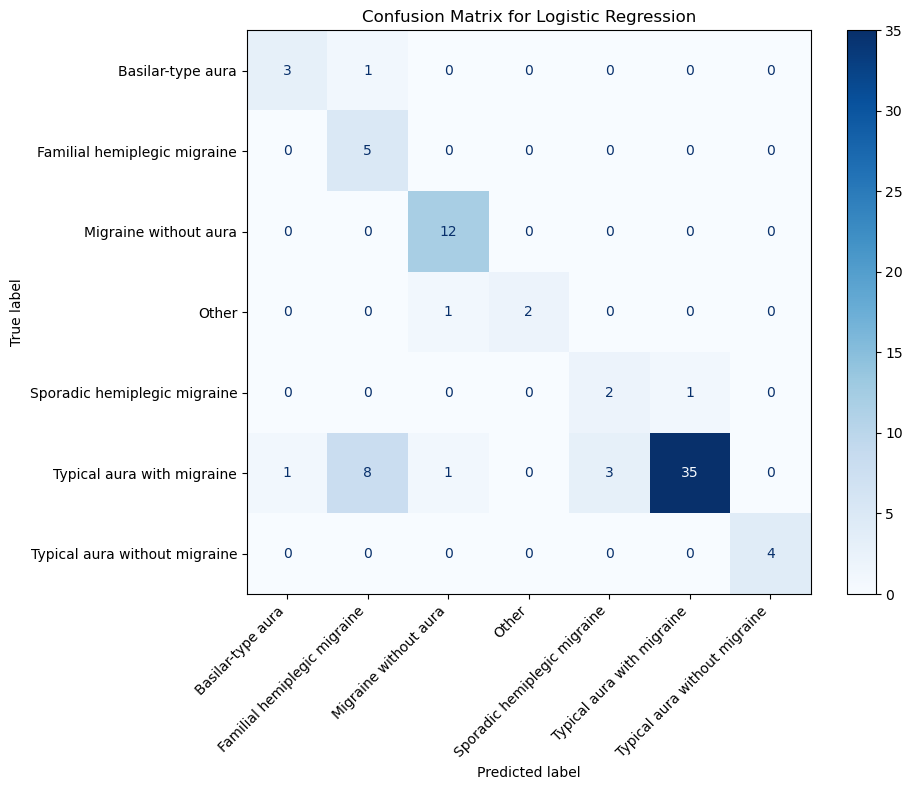


Model: Random Forest
Classification Report:
                                precision    recall  f1-score   support

            Basilar-type aura       0.67      0.50      0.57         4
 Familial hemiplegic migraine       0.57      0.80      0.67         5
        Migraine without aura       0.92      1.00      0.96        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       0.67      0.67      0.67         3
   Typical aura with migraine       0.96      0.94      0.95        48
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.90        79
                    macro avg       0.83      0.80      0.80        79
                 weighted avg       0.91      0.90      0.90        79



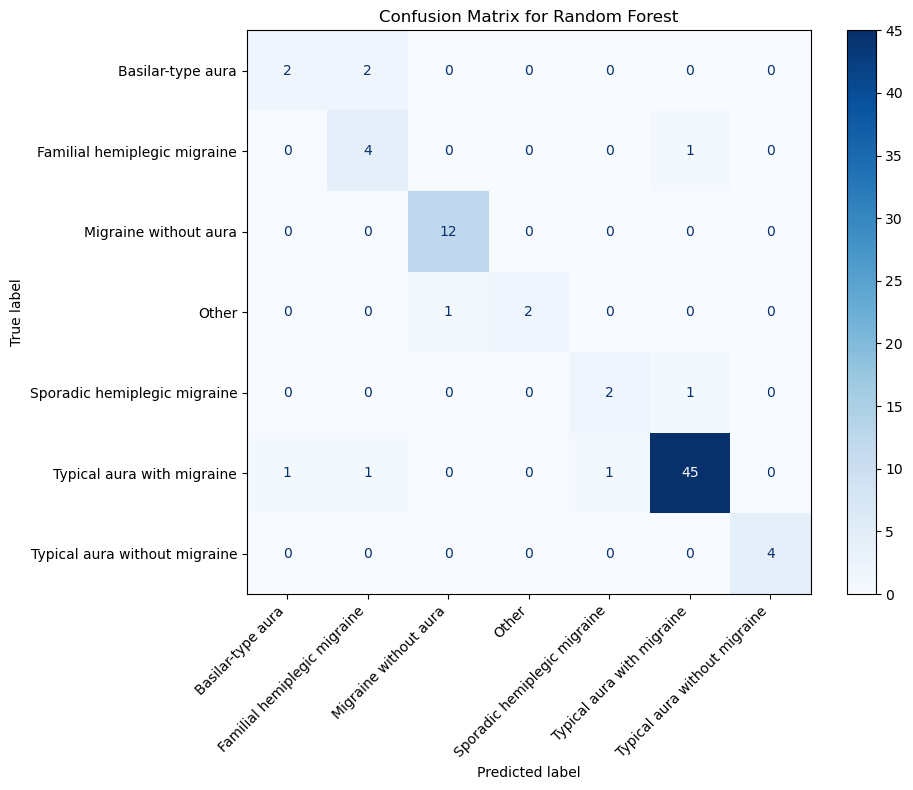


Model: XGBoost
Classification Report:
                                precision    recall  f1-score   support

            Basilar-type aura       0.75      0.75      0.75         4
 Familial hemiplegic migraine       0.67      0.80      0.73         5
        Migraine without aura       0.92      1.00      0.96        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       0.67      0.67      0.67         3
   Typical aura with migraine       0.96      0.94      0.95        48
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.91        79
                    macro avg       0.85      0.83      0.84        79
                 weighted avg       0.92      0.91      0.91        79



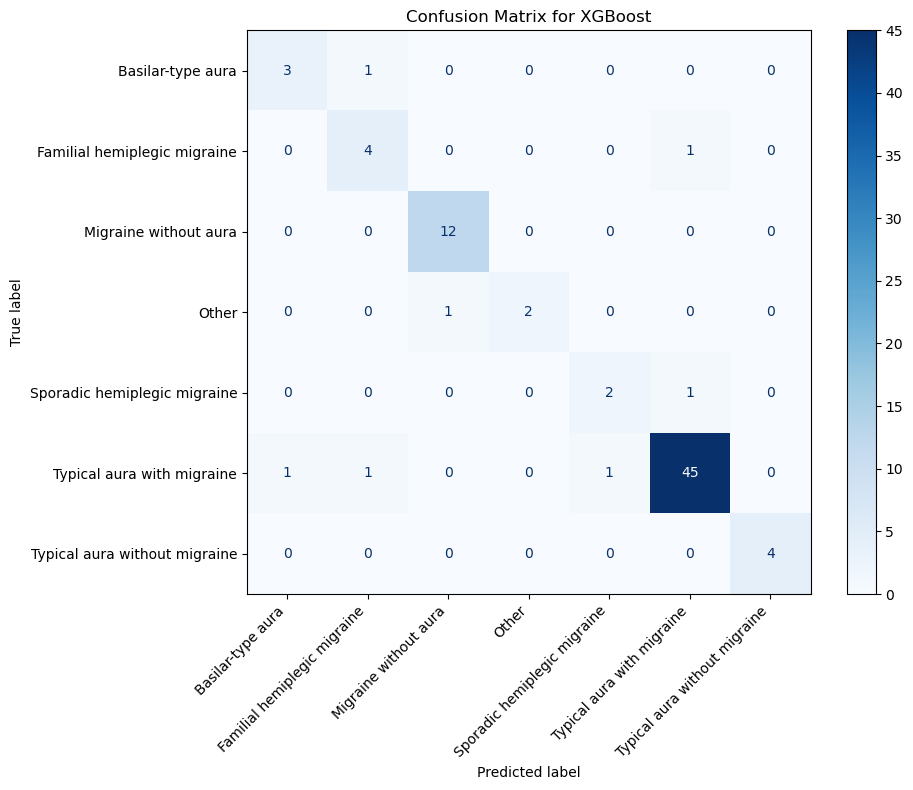

In [17]:
# Train and Evaluate models
# Fit each model, make predictions
# Print performance reports and confusion matrices
for name, model in models.items():
    print(f"\nModel: {name}")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    print("Classification Report:\n",
          classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)

    # Plot with custom size
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels and align right
    plt.title(f"Confusion Matrix for {name}")
    plt.tight_layout()  # Prevent clipping of labels
    plt.show()

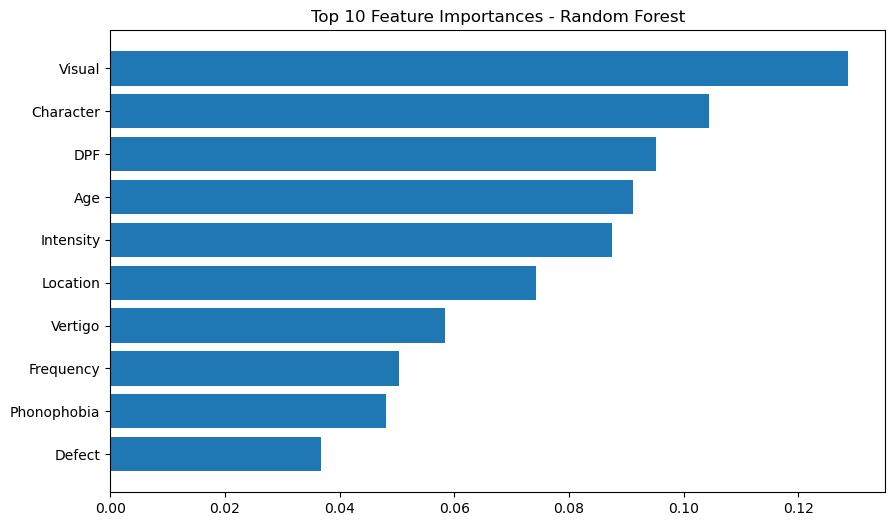

In [18]:
# Display which feaures contribute most to the Random Forst Model's predictions
rf = models['Random Forest']
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:][::-1]
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [19]:
# Compute ROC-AUC Scores for the models to see overall classifier performance
def multiclass_roc_auc_score(y_test, y_pred, average="macro"):
    y_test_bin = pd.get_dummies(y_test)
    y_pred_bin = pd.get_dummies(y_pred)
    return roc_auc_score(y_test_bin, y_pred_bin, average=average)

for name, model in models.items():
    y_pred = model.predict(X_test)
    auc = multiclass_roc_auc_score(y_test, y_pred)
    print(f"ROC-AUC Score ({name}): {auc:.4f}")

ROC-AUC Score (Logistic Regression): 0.8983
ROC-AUC Score (Random Forest): 0.8875
ROC-AUC Score (XGBoost): 0.9063
